In [1]:
## Install missingno for missing value visualization
!pip install missingno -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## 📊 Data Visualization & Insights


In [2]:
# Load all required CSV files
df_players       = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/players.csv')
df_valuations    = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/player_valuations.csv')
df_appearances   = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/appearances.csv')
df_competitions  = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/competitions.csv')
df_clubs         = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/clubs.csv')
df_transfers     = pd.read_csv('/kaggle/input/datasets/davidcariboo/player-scores/transfers.csv')

print("All datasets loaded successfully!")
print(f"players:        {df_players.shape}")
print(f"valuations:     {df_valuations.shape}")
print(f"appearances:    {df_appearances.shape}")
print(f"competitions:   {df_competitions.shape}")
print(f"clubs:          {df_clubs.shape}")
print(f"transfers:      {df_transfers.shape}")

All datasets loaded successfully!
players:        (34376, 23)
valuations:     (525510, 6)
appearances:    (1747138, 13)
competitions:   (44, 11)
clubs:          (451, 17)
transfers:      (100266, 10)


In [3]:
#Print Top Rows of Each Dataset
print("=" * 60)
print("PLAYERS.CSV - Top 5 Rows")
print("=" * 60)
display(df_players.head())

print("=" * 60)
print("PLAYER_VALUATIONS.CSV - Top 5 Rows")
print("=" * 60)
display(df_valuations.head())

print("=" * 60)
print("APPEARANCES.CSV - Top 5 Rows")
print("=" * 60)
display(df_appearances.head())

print("=" * 60)
print("COMPETITIONS.CSV - Top 5 Rows")
print("=" * 60)
display(df_competitions.head())

print("=" * 60)
print("CLUBS.CSV - Top 5 Rows")
print("=" * 60)
display(df_clubs.head())

print("=" * 60)
print("TRANSFERS.CSV - Top 5 Rows")
print("=" * 60)
display(df_transfers.head())

PLAYERS.CSV - Top 5 Rows


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


PLAYER_VALUATIONS.CSV - Top 5 Rows


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


APPEARANCES.CSV - Top 5 Rows


...

,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,url,is_major_national_league
0,BE1,jupiler-pro-league,jupiler-pro-league,first_tier,domestic_league,19,Belgium,BE1,europa,https://www.transfermarkt.co.uk/jupiler-pro-le...,False
1,BESC,belgian-supercup,belgian-supercup,domestic_super_cup,other,19,Belgium,BE1,europa,https://www.transfermarkt.co.uk/belgian-superc...,False
2,CDR,copa-del-rey,copa-del-rey,domestic_cup,domestic_cup,157,Spain,ES1,europa,https://www.transfermarkt.co.uk/copa-del-rey/s...,False
3,CGB,efl-cup,efl-cup,league_cup,other,189,England,GB1,europa,https://www.transfermarkt.co.uk/efl-cup/starts...,False
4,CIT,italy-cup,italy-cup,domestic_cup,domestic_cup,75,Italy,IT1,europa,https://www.transfermarkt.co.uk/italy-cup/star...,False


CLUBS.CSV - Top 5 Rows


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,10,arminia-bielefeld,Arminia Bielefeld,L1,NaN,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
1,10004,paris-fc,Paris Football Club,FR1,NaN,31,28.5,17,54.8,9,Stade Jean Bouin,19904,€-72.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paris-fc/start...
2,1003,leicester-city,Leicester City,GB1,NaN,29,25.8,17,58.6,10,King Power Stadium,32259,+€57.30m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/leicester-city...
3,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.1,23,85.2,10,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...
4,1010,fc-watford,Watford FC,GB1,NaN,30,26.3,24,80.0,12,Vicarage Road,21577,+€42.02m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/fc-watford/sta...


TRANSFERS.CSV - Top 5 Rows


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,1077560,2027-06-30,26/27,3060,683,Atromitos,Olympiacos,0.0,1000000.0,Stavros Pnevmonidis
2,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.0,NaN,Yannick Nkurunziza
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan
4,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.0,6000000.0,Monchu


In [4]:
#Statistical Description (.describe())

print("=" * 60)
print("PLAYERS - Statistical Description")
print("=" * 60)
display(df_players.describe(include='all'))

print("=" * 60)
print("PLAYER VALUATIONS - Statistical Description")
print("=" * 60)
display(df_valuations.describe(include='all'))

print("=" * 60)
print("APPEARANCES - Statistical Description")
print("=" * 60)
display(df_appearances.describe(include='all'))

print("=" * 60)
print("CLUBS - Statistical Description")
print("=" * 60)
display(df_clubs.describe(include='all'))

print("=" * 60)
print("TRANSFERS - Statistical Description")
print("=" * 60)
display(df_transfers.describe(include='all'))

PLAYERS - Statistical Description


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
count,3.437600e+04,32238,34376,34376,34376.000000,34376.000000,34376,31469,31791,34024,...,31718,31982.000000,21904,17807,34376,34376,34376,34376,3.262900e+04,3.262900e+04
unique,NaN,7365,24905,33623,NaN,NaN,33577,186,8844,186,...,3,NaN,141,3079,28667,34376,14,449,NaN,NaN
top,NaN,David,García,Paulinho,NaN,NaN,paulinho,France,London,Spain,...,right,NaN,2023-06-30 00:00:00,Wasserman,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/yaya-onogo/pro...,TR1,Kilmarnock Football Club,NaN,NaN
freq,NaN,224,71,12,NaN,NaN,12,2457,505,2065,...,22302,NaN,4402,594,5710,1,3432,198,NaN,NaN
mean,3.797402e+05,NaN,NaN,NaN,2019.851263,5098.695078,NaN,NaN,NaN,NaN,...,NaN,182.363110,NaN,NaN,NaN,NaN,NaN,NaN,1.672454e+06,3.905989e+06
std,3.137617e+05,NaN,NaN,NaN,4.254714,12477.070256,NaN,NaN,NaN,NaN,...,NaN,7.019999,NaN,NaN,NaN,NaN,NaN,NaN,6.453765e+06,1.014348e+07
min,1.000000e+01,NaN,NaN,NaN,2012.000000,3.000000,NaN,NaN,NaN,NaN,...,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+04,1.000000e+04
25%,1.190840e+05,NaN,NaN,NaN,2016.000000,403.000000,NaN,NaN,NaN,NaN,...,NaN,178.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+05,3.000000e+05
50%,2.992335e+05,NaN,NaN,NaN,2021.000000,1082.000000,NaN,NaN,NaN,NaN,...,NaN,183.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.500000e+05,8.000000e+05
75%,5.748028e+05,NaN,NaN,NaN,2024.000000,3205.000000,NaN,NaN,NaN,NaN,...,NaN,187.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+05,3.000000e+06


PLAYER VALUATIONS - Statistical Description


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
count,5.255100e+05,525510,5.255100e+05,525510,525510.000000,469035
unique,NaN,5527,NaN,6838,NaN,14
top,NaN,2020-04-08,NaN,Without Club,NaN,IT1
freq,NaN,10509,NaN,4074,NaN,51680
mean,2.447999e+05,NaN,2.560222e+06,NaN,4825.647613,NaN
std,2.289660e+05,NaN,7.228201e+06,NaN,11097.919302,NaN
min,1.000000e+01,NaN,0.000000e+00,NaN,1.000000,NaN
25%,6.165300e+04,NaN,2.000000e+05,NaN,379.000000,NaN
50%,1.784000e+05,NaN,5.000000e+05,NaN,1053.000000,NaN
75%,3.534030e+05,NaN,1.800000e+06,NaN,3336.000000,NaN


APPEARANCES - Statistical Description


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
count,1747138,1.747138e+06,1.747138e+06,1.747138e+06,1.747138e+06,1747138,1747134,1747138,1.747138e+06,1.747138e+06,1.747138e+06,1.747138e+06,1.747138e+06
unique,1747138,NaN,NaN,NaN,NaN,4021,26166,43,NaN,NaN,NaN,NaN,NaN
top,4805911_84301,NaN,NaN,NaN,NaN,2025-11-09,Danilo,ES1,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,1819,1156,143598,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.210806e+06,2.202432e+05,3.179172e+03,4.188385e+03,NaN,NaN,NaN,1.465774e-01,3.799356e-03,9.582014e-02,7.542507e-02,6.894055e+01
std,NaN,7.137937e+05,2.078494e+05,8.512423e+03,1.133757e+04,NaN,NaN,NaN,3.646199e-01,6.152173e-02,3.307211e-01,2.854169e-01,3.003550e+01
min,NaN,2.211607e+06,1.000000e+01,1.000000e+00,-1.000000e+00,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,NaN,2.594474e+06,5.908400e+04,2.810000e+02,3.360000e+02,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.500000e+01
50%,NaN,3.093827e+06,1.579790e+05,8.250000e+02,9.320000e+02,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
75%,NaN,3.837940e+06,3.226550e+05,2.439000e+03,2.698000e+03,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01


CLUBS - Statistical Description


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
count,451.000000,451,451,451,0.0,451.000000,413.000000,451.000000,399.000000,451.000000,451,451.000000,451,0.0,451.000000,451,451
unique,NaN,451,451,14,NaN,NaN,NaN,NaN,NaN,NaN,431,NaN,311,NaN,NaN,14,451
top,NaN,fc-nantes,Football Club de Nantes,TR1,NaN,NaN,NaN,NaN,NaN,NaN,Obolon-Arena,NaN,+-0,NaN,NaN,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/fc-nantes/star...
freq,NaN,1,1,43,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,96,NaN,NaN,236,1
mean,6748.266075,NaN,NaN,NaN,NaN,24.399113,25.492010,11.463415,47.544361,4.720621,NaN,23834.456763,NaN,NaN,2022.228381,NaN,NaN
std,15749.644024,NaN,NaN,NaN,NaN,8.747845,2.389887,7.006687,20.863592,4.915011,NaN,17217.265379,NaN,NaN,3.909384,NaN,NaN
min,3.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,2.400000,0.000000,NaN,0.000000,NaN,NaN,2012.000000,NaN,NaN
25%,446.000000,NaN,NaN,NaN,NaN,25.000000,24.500000,6.000000,31.000000,1.000000,NaN,10522.500000,NaN,NaN,2020.000000,NaN,NaN
50%,1184.000000,NaN,NaN,NaN,NaN,27.000000,25.700000,12.000000,50.000000,3.000000,NaN,19979.000000,NaN,NaN,2025.000000,NaN,NaN
75%,3700.000000,NaN,NaN,NaN,NaN,29.000000,26.700000,17.000000,64.000000,7.000000,NaN,31803.000000,NaN,NaN,2025.000000,NaN,NaN


TRANSFERS - Statistical Description


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
count,1.002660e+05,100266,100266,100266.000000,100266.000000,100266,100266,6.588100e+04,6.184700e+04,100266
unique,NaN,4607,34,NaN,NaN,11685,9082,NaN,NaN,12559
top,NaN,2022-07-01,23/24,NaN,NaN,Without Club,Without Club,NaN,NaN,João Pedro
freq,NaN,2988,10196,NaN,NaN,1362,1982,NaN,NaN,38
mean,4.740785e+05,NaN,NaN,18330.904324,14044.726119,NaN,NaN,1.076703e+06,2.428602e+06,NaN
std,2.984858e+05,NaN,NaN,25461.910175,22289.206927,NaN,NaN,5.213457e+06,5.801530e+06,NaN
min,3.333000e+03,NaN,NaN,1.000000,1.000000,NaN,NaN,0.000000e+00,1.000000e+04,NaN
25%,2.382660e+05,NaN,NaN,873.000000,614.000000,NaN,NaN,0.000000e+00,2.000000e+05,NaN
50%,4.168020e+05,NaN,NaN,6808.000000,3225.000000,NaN,NaN,0.000000e+00,6.000000e+05,NaN
75%,6.671210e+05,NaN,NaN,26459.000000,15595.000000,NaN,NaN,0.000000e+00,2.000000e+06,NaN


In [5]:
#Checking for missing Values

datasets = {
    'players': df_players,
    'player_valuations': df_valuations,
    'appearances': df_appearances,
    'competitions': df_competitions,
    'clubs': df_clubs,
    'transfers': df_transfers
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    
    if not missing_df.empty:
        print(f"\n{'='*60}")
        print(f"Missing Values in: {name.upper()}")
        print(f"{'='*60}")
        display(missing_df)
    else:
        print(f"\n{name.upper()} — No missing values found!")


Missing Values in: PLAYERS


,Missing Count,Missing %
agent_name,16569,48.199325
contract_expiration_date,12472,36.281126
country_of_birth,2907,8.456481
foot,2658,7.732139
city_of_birth,2585,7.519781
height_in_cm,2394,6.964161
first_name,2138,6.219455
market_value_in_eur,1747,5.082034
highest_market_value_in_eur,1747,5.082034
country_of_citizenship,352,1.023970



Missing Values in: PLAYER_VALUATIONS


,Missing Count,Missing %
player_club_domestic_competition_id,56475,10.746703



Missing Values in: APPEARANCES


...

,Missing Count,Missing %
country_name,8,18.181818
domestic_league_code,8,18.181818



Missing Values in: CLUBS


,Missing Count,Missing %
total_market_value,451,100.000000
coach_name,451,100.000000
foreigners_percentage,52,11.529933
average_age,38,8.425721



Missing Values in: TRANSFERS


,Missing Count,Missing %
market_value_in_eur,38419,38.317077
transfer_fee,34385,34.293779


In [6]:
#Checking DataTypes 

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"Data Types: {name.upper()}")
    print(f"{'='*60}")
    print(df.dtypes)


Data Types: PLAYERS
player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
url                                      object
current_club_domestic_competition_id     object
current_club_name  

## Data Visualization



<Figure size 1400x600 with 0 Axes>

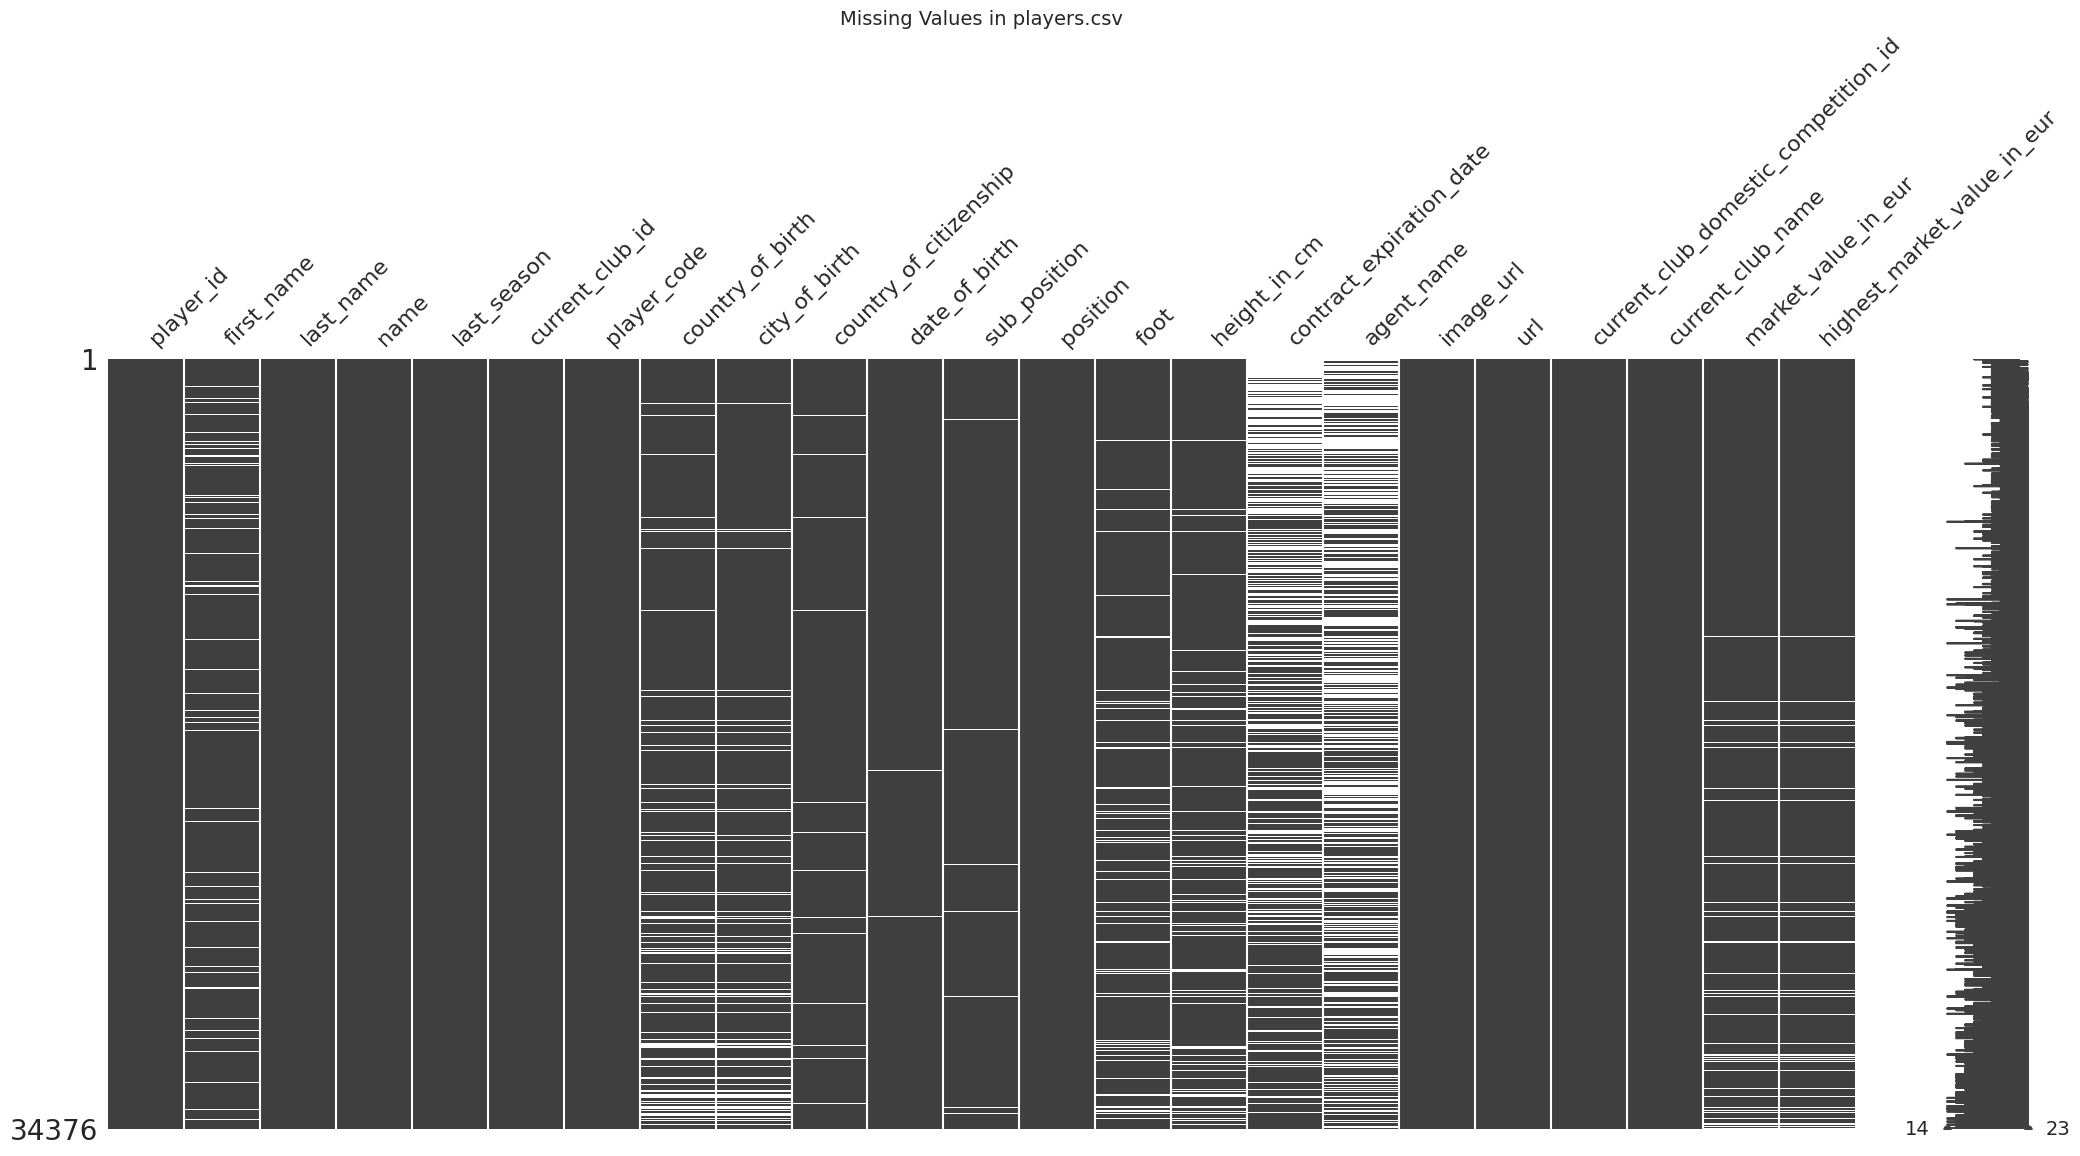

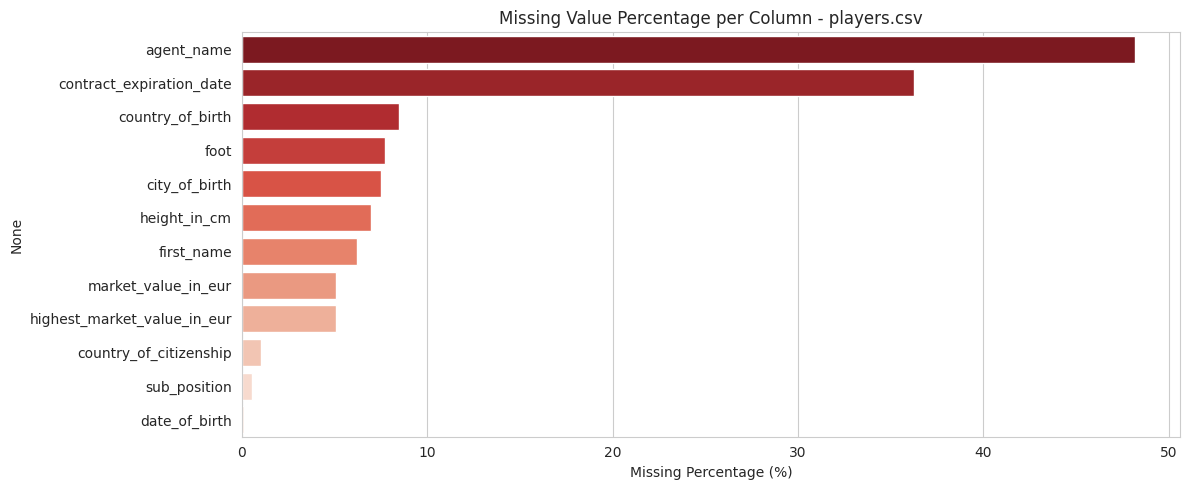

In [7]:
#Missing Value Heatmap and Barchart 

plt.figure(figsize=(14, 6))
msno.matrix(df_players)
plt.title("Missing Values in players.csv", fontsize=14)
plt.tight_layout()
plt.show()

missing_pct = df_players.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')
plt.xlabel("Missing Percentage (%)")
plt.title("Missing Value Percentage per Column - players.csv")
plt.tight_layout()
plt.show()

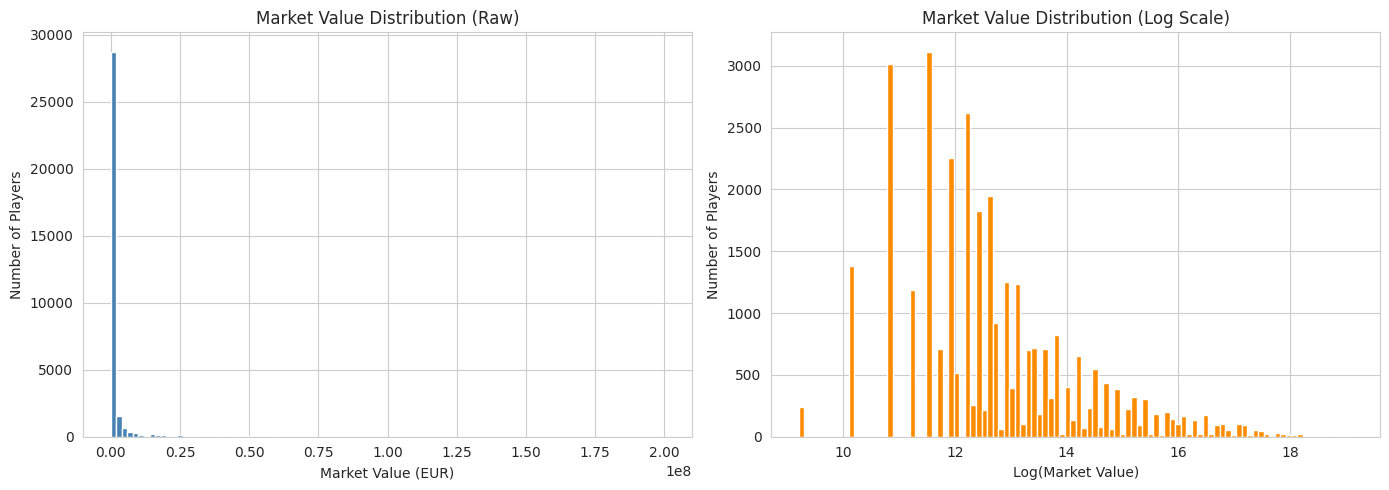

In [8]:
# Distribution of Market Value
df_mv = df_players.dropna(subset=['market_value_in_eur'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_mv['market_value_in_eur'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title("Market Value Distribution (Raw)")
axes[0].set_xlabel("Market Value (EUR)")
axes[0].set_ylabel("Number of Players")

# Log distribution (better to visualize skewed data)
axes[1].hist(np.log1p(df_mv['market_value_in_eur']), bins=100, color='darkorange', edgecolor='white')
axes[1].set_title("Market Value Distribution (Log Scale)")
axes[1].set_xlabel("Log(Market Value)")
axes[1].set_ylabel("Number of Players")

plt.tight_layout()
plt.show()

# Note: Market value is heavily right-skewed. Most players have low values while a small number of elite players have extremely high values. Log transformation makes the distribution more normal — this will be useful for the ML model.

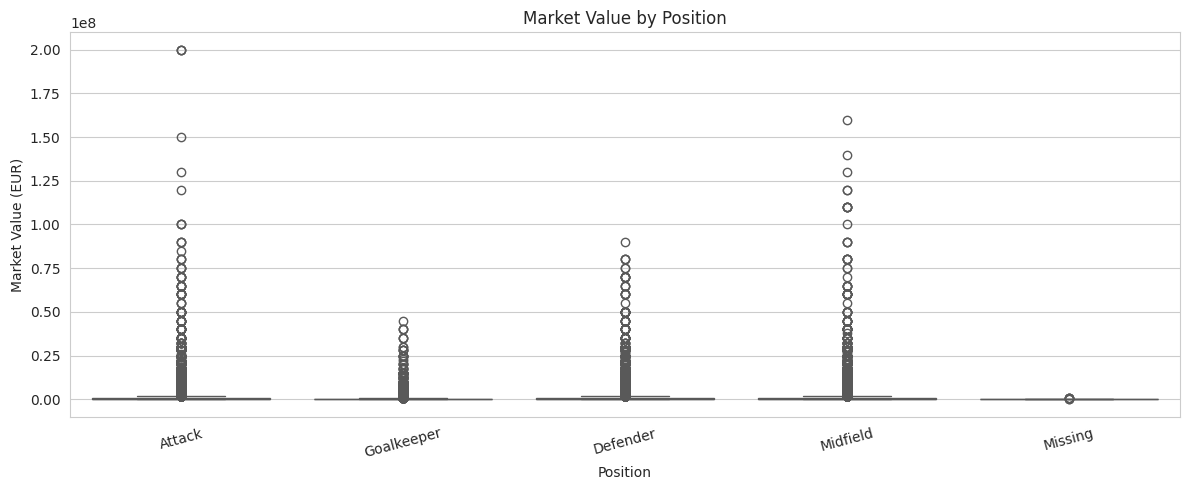

In [9]:
#Market Value by Position

df_pos = df_players.dropna(subset=['market_value_in_eur', 'position'])

plt.figure(figsize=(12, 5))
sns.boxplot(x='position', y='market_value_in_eur', data=df_pos, palette='Set2')
plt.title("Market Value by Position")
plt.xlabel("Position")
plt.ylabel("Market Value (EUR)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#Note: Attackers and midfielders generally command higher market values compared to goalkeepers and defenders.

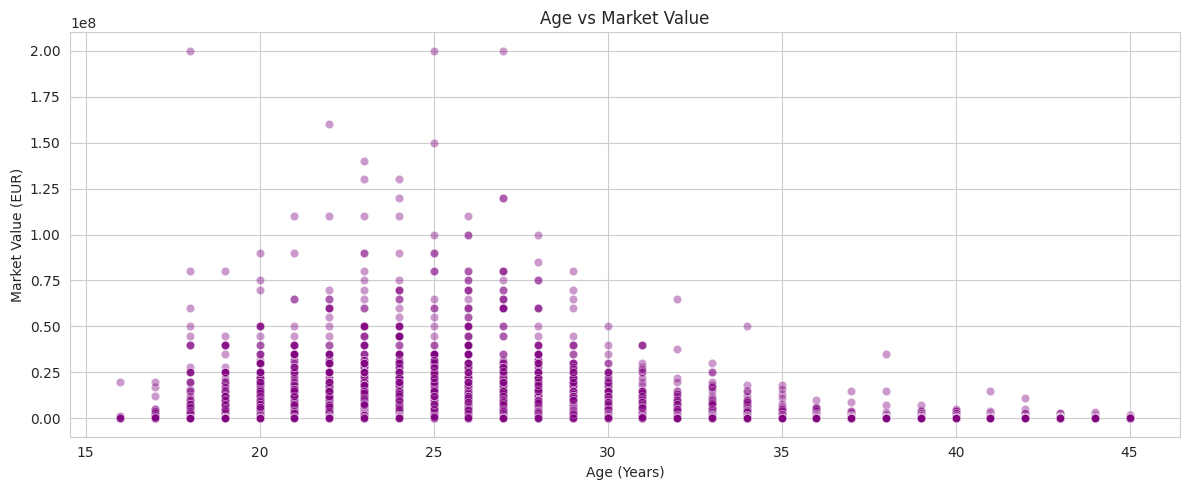

In [10]:
#Age vs Market Value
# Calculate age first
df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')
df_players['age'] = (pd.Timestamp.now() - df_players['date_of_birth']).dt.days // 365

df_age = df_players.dropna(subset=['age', 'market_value_in_eur'])
df_age = df_age[(df_age['age'] >= 15) & (df_age['age'] <= 45)]

plt.figure(figsize=(12, 5))
sns.scatterplot(x='age', y='market_value_in_eur', data=df_age, alpha=0.4, color='purple')
plt.title("Age vs Market Value")
plt.xlabel("Age (Years)")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

#Note: Market value peaks around ages 23–28 and declines significantly after 30. This bell-curve pattern is expected in football.

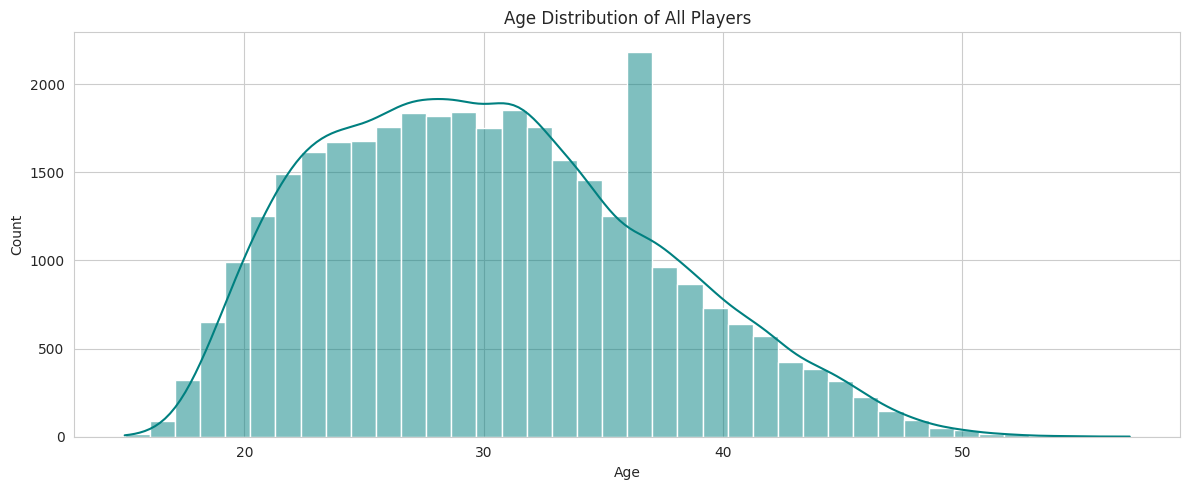

In [11]:
#Age Distribution of Players

plt.figure(figsize=(12, 5))
sns.histplot(df_players['age'].dropna(), bins=40, kde=True, color='teal')
plt.title("Age Distribution of All Players")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

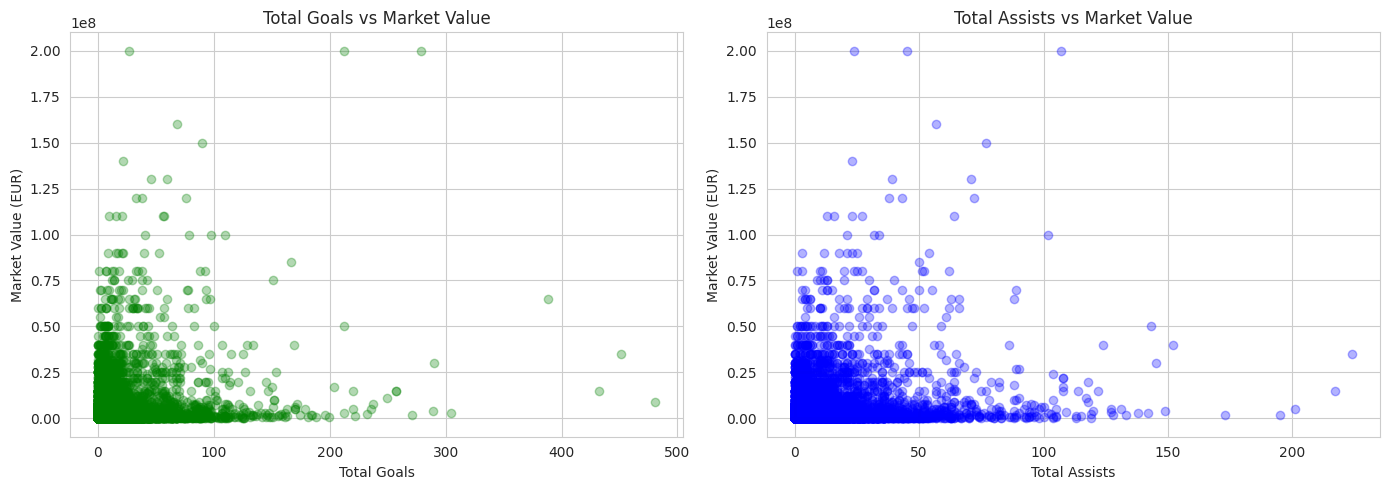

In [12]:
#Goals & Assists vs Market Value

# Aggregate appearances per player
agg = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes=('minutes_played', 'sum')
).reset_index()

# Merge with players
df_merged_temp = df_players.dropna(subset=['market_value_in_eur']).merge(agg, on='player_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_merged_temp['total_goals'], df_merged_temp['market_value_in_eur'], alpha=0.3, color='green')
axes[0].set_title("Total Goals vs Market Value")
axes[0].set_xlabel("Total Goals")
axes[0].set_ylabel("Market Value (EUR)")

axes[1].scatter(df_merged_temp['total_assists'], df_merged_temp['market_value_in_eur'], alpha=0.3, color='blue')
axes[1].set_title("Total Assists vs Market Value")
axes[1].set_xlabel("Total Assists")
axes[1].set_ylabel("Market Value (EUR)")

plt.tight_layout()
plt.show()

#Note: There is a positive correlation — players with more goals and assists tend to have higher market values, especially strikers and attacking midfielders.

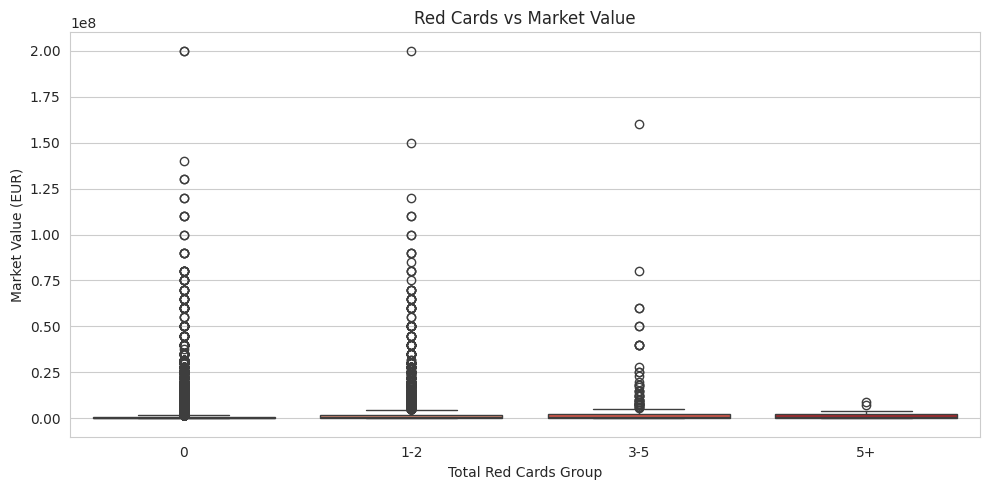

In [13]:
# ============================================================
# Red Cards vs Market Value (Grouped Boxplot)
# We group players by how many red cards they have received
# and compare their market values. This shows whether
# disciplinary issues negatively impact a player's value.
# ============================================================

plt.figure(figsize=(10, 5))
sns.boxplot(
    x=pd.cut(df_merged_temp['total_red_cards'],
             bins=[-1, 0, 2, 5, 100],
             labels=['0', '1-2', '3-5', '5+']),
    y='market_value_in_eur',
    data=df_merged_temp,
    palette='Reds'
)
plt.title("Red Cards vs Market Value")
plt.xlabel("Total Red Cards Group")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

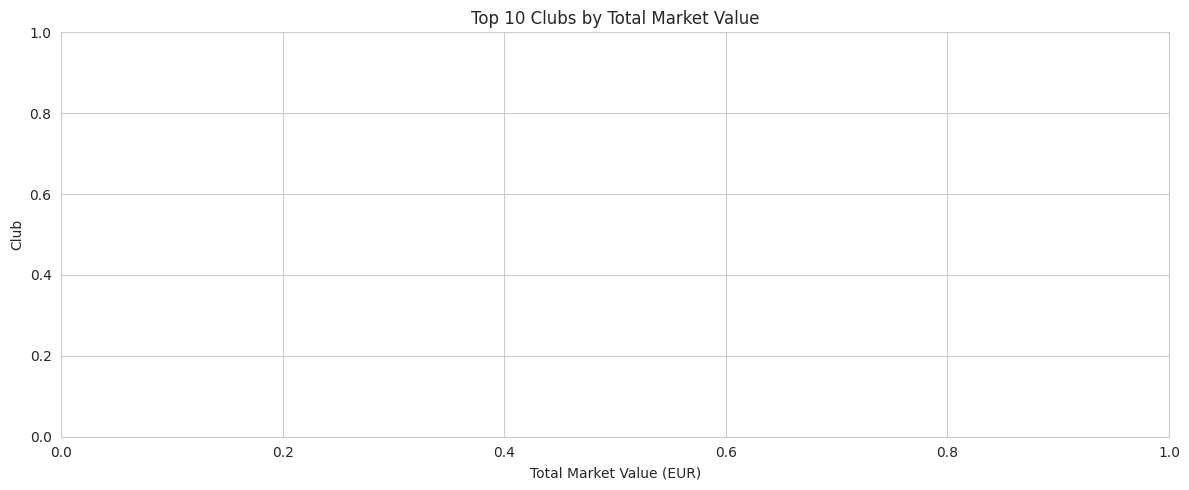

In [14]:
# ============================================================
# Top 10 Clubs by Total Squad Market Value
# A horizontal bar chart ranking clubs by combined squad value.
# This helps identify which clubs have the highest quality
# squads and answers our research question about top clubs.
# ============================================================

df_clubs_clean_viz = df_clubs.dropna(subset=['total_market_value'])
top_clubs = df_clubs_clean_viz.nlargest(10, 'total_market_value')

plt.figure(figsize=(12, 5))
sns.barplot(x='total_market_value', y='name', data=top_clubs, palette='Blues_r')
plt.title("Top 10 Clubs by Total Market Value")
plt.xlabel("Total Market Value (EUR)")
plt.ylabel("Club")
plt.tight_layout()
plt.show()

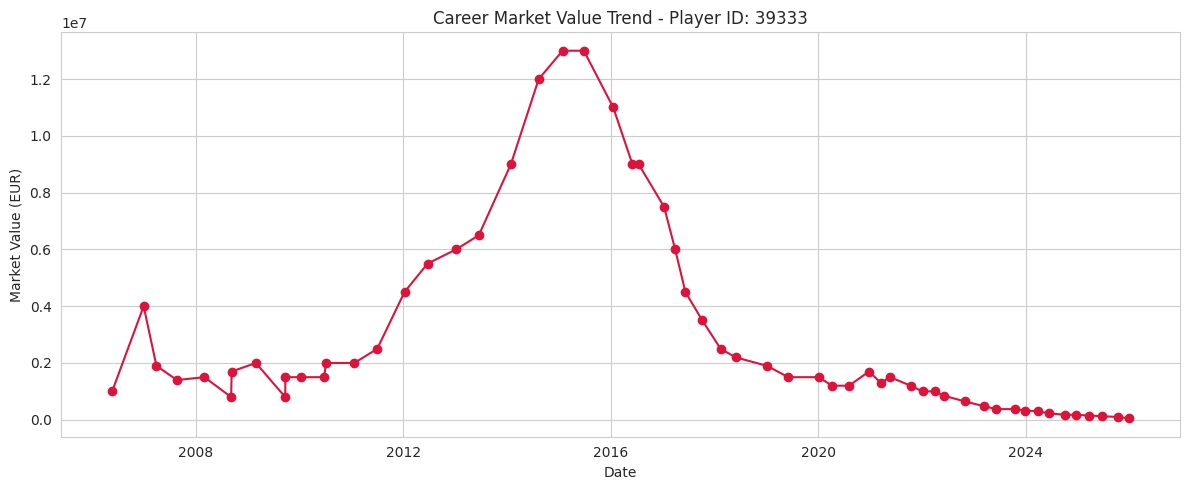

In [15]:
# ============================================================
#  Career Market Value Trend for a Single Player
# We pick the player with the most valuation records and plot
# their value over time. This directly answers our research
# question: "How does market value change throughout a career?"
# ============================================================

df_valuations['date'] = pd.to_datetime(df_valuations['date'], errors='coerce')

top_player_id = df_valuations['player_id'].value_counts().idxmax()
sample = df_valuations[df_valuations['player_id'] == top_player_id].sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(sample['date'], sample['market_value_in_eur'], marker='o', color='crimson')
plt.title(f"Career Market Value Trend - Player ID: {top_player_id}")
plt.xlabel("Date")
plt.ylabel("Market Value (EUR)")
plt.tight_layout()
plt.show()

#Note: This plot shows how a single player's market value rises and falls throughout their career — useful for time-series analysis in later phases.

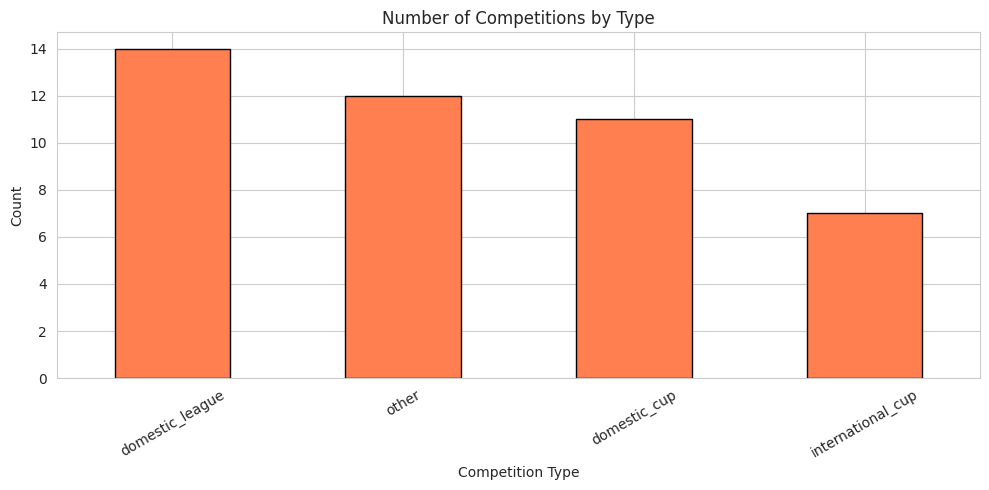

In [16]:
# ============================================================
# Number of Competitions by Type
# This bar chart shows how many domestic, international, and
# other competition types exist in the dataset. Helps us
# understand the competition level diversity in our data.
# ============================================================

df_comp_clean_viz = df_competitions.dropna(subset=['type'])

plt.figure(figsize=(10, 5))
df_comp_clean_viz['type'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title("Number of Competitions by Type")
plt.xlabel("Competition Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

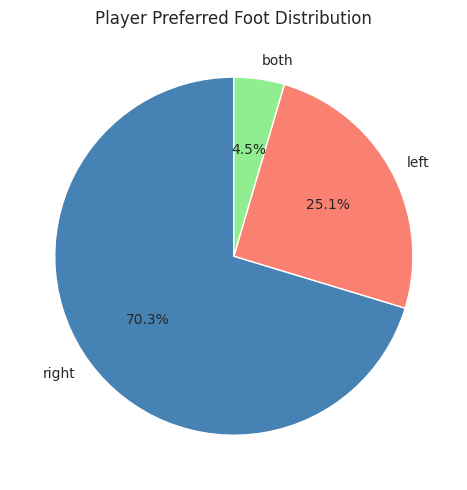

In [17]:
# ============================================================
# Player Preferred Foot Distribution (Pie Chart)
# Shows the ratio of right-footed, left-footed and both-footed
# players. Left-footed players are rarer and often valued
# higher — this feature may have ML signal.
# ============================================================

plt.figure(figsize=(7, 5))
df_players['foot'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['steelblue', 'salmon', 'lightgreen'],
    startangle=90
)
plt.title("Player Preferred Foot Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

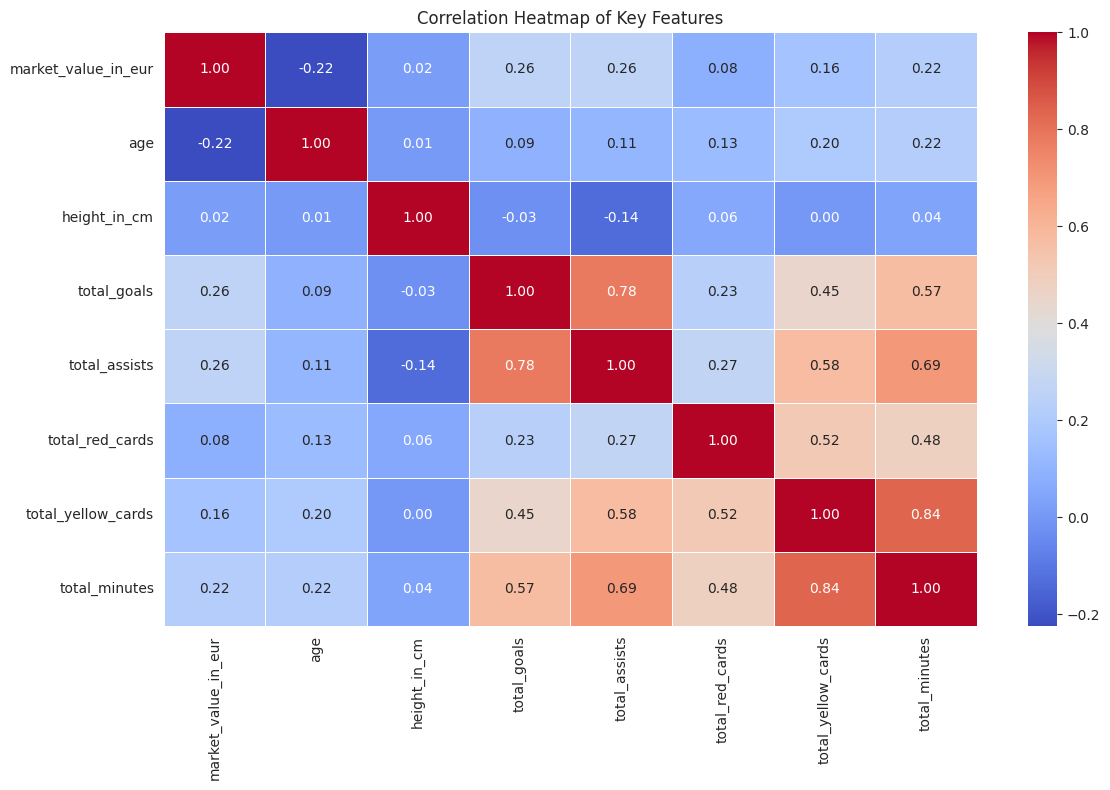

In [18]:
# ============================================================
# Correlation Heatmap of All Key Numeric Features
# Shows how strongly each feature is correlated with others
# and with market value. Strong correlations (close to 1 or -1)
# indicate important features for the ML model.
# ============================================================

numeric_cols = ['market_value_in_eur', 'age', 'height_in_cm',
                'total_goals', 'total_assists', 'total_red_cards',
                'total_yellow_cards', 'total_minutes']

corr_df = df_merged_temp[numeric_cols].dropna()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Key Features")
plt.tight_layout()
plt.show()

#Note: total_goals, total_assists, and total_minutes show positive correlation with market value. Age shows a moderate relationship.

In [19]:
# ============================================================
# Drop Irrelevant Columns from players.csv
# REASON: image_url, url, player_code are web links and system
# identifiers with zero predictive value. first_name and
# last_name are redundant since the 'name' column exists.
# city_of_birth has too many unique values (high cardinality)
# and very little signal for market value prediction.
# ============================================================

cols_to_drop = ['first_name', 'last_name', 'player_code',
                'image_url', 'url', 'city_of_birth']

df_players.drop(columns=[c for c in cols_to_drop if c in df_players.columns], inplace=True)

print("Remaining columns in players.csv:")
print(df_players.columns.tolist())

Remaining columns in players.csv:
['player_id', 'name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'age']


In [20]:
# ============================================================
# Remove Rows with Missing Market Value
# REASON: market_value_in_eur is our target variable (the value
# we want to predict). Any row without this value is completely
# useless for supervised ML training and must be removed.
# ============================================================

before = len(df_players)
df_players.dropna(subset=['market_value_in_eur'], inplace=True)
after = len(df_players)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Rows dropped: {before - after}")

Rows before: 34376
Rows after:  32629
Rows dropped: 1747


In [21]:
# ============================================================
# Handle Missing Values in players.csv
# REASON: Columns with >50% missing cannot provide reliable
# information to a model and are dropped. height_in_cm is
# filled with median (not mean) to avoid outlier influence.
# foot and position are filled with mode (most common value)
# since they are categorical columns.
# ============================================================

# Drop columns where more than 50% data is missing
threshold = 0.5
cols_before = df_players.shape[1]
df_players = df_players.dropna(thresh=int(len(df_players) * threshold), axis=1)
cols_after = df_players.shape[1]
print(f"Columns dropped due to >50% missing: {cols_before - cols_after}")

# Fill height with median
if 'height_in_cm' in df_players.columns:
    median_height = df_players['height_in_cm'].median()
    df_players['height_in_cm'].fillna(median_height, inplace=True)
    print(f"Filled height_in_cm with median: {median_height}")

# Fill foot with mode
if 'foot' in df_players.columns:
    df_players['foot'].fillna(df_players['foot'].mode()[0], inplace=True)
    print(f"Filled foot with mode: {df_players['foot'].mode()[0]}")

# Fill position with mode
if 'position' in df_players.columns:
    df_players['position'].fillna(df_players['position'].mode()[0], inplace=True)

print("\nRemaining missing values in players.csv:")
print(df_players.isnull().sum()[df_players.isnull().sum() > 0])

Columns dropped due to >50% missing: 0
Filled height_in_cm with median: 183.0
Filled foot with mode: right

Remaining missing values in players.csv:
country_of_birth             2212
country_of_citizenship        336
date_of_birth                  33
sub_position                  104
contract_expiration_date    11617
agent_name                  15387
age                            33
dtype: int64


In [22]:
# ============================================================
# Convert date_of_birth Column to Numeric Age
# REASON: ML models cannot process raw date strings. We convert
# date_of_birth into a numeric 'age' feature (in years) which
# the model can directly use. The original date column is then
# dropped since age captures all the needed information.
# ============================================================

df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')
df_players['age'] = (pd.Timestamp.now() - df_players['date_of_birth']).dt.days // 365
df_players.drop(columns=['date_of_birth'], inplace=True)

print("Age column created successfully. Sample values:")
print(df_players['age'].describe())

Age column created successfully. Sample values:
count    32596.000000
mean        30.537796
std          6.746851
min         16.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         56.000000
Name: age, dtype: float64


In [23]:
# ============================================================
# Label Encode Categorical Columns
# REASON: ML algorithms require numeric inputs. Columns like
# position ('Attack', 'Defence'), foot ('Left', 'Right'), and
# country_of_citizenship contain text values. We use Label
# Encoding to convert them to numeric codes the model can use.
# ============================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['position', 'sub_position', 'foot', 'country_of_citizenship']

for col in cat_cols:
    if col in df_players.columns:
        df_players[col] = df_players[col].astype(str)
        df_players[col + '_encoded'] = le.fit_transform(df_players[col])
        print(f"Encoded: {col}")

print("\nEncoding complete!")

Encoded: position
Encoded: sub_position
Encoded: foot
Encoded: country_of_citizenship

Encoding complete!


In [24]:
# ============================================================
# Aggregate Player Performance Stats from appearances.csv
# REASON: appearances.csv has one row per match per player which
# means thousands of rows per player. For ML, we need one row
# per player. We aggregate by summing goals, assists, cards and
# minutes so each player has a single performance summary row.
# ============================================================

agg_appearances = df_appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_red_cards=('red_cards', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_minutes_played=('minutes_played', 'sum'),
    total_games=('appearance_id', 'count')
).reset_index()

print("Aggregated appearances shape:", agg_appearances.shape)
display(agg_appearances.head())

Aggregated appearances shape: (26732, 7)


,player_id,total_goals,total_assists,total_red_cards,total_yellow_cards,total_minutes_played,total_games
0,10,48,25,0,19,8808,136
1,26,0,0,2,4,13508,152
2,65,38,13,1,11,8788,122
3,77,0,0,0,0,307,4
4,80,0,0,0,0,1080,12


In [25]:
# ============================================================
# Clean clubs.csv - Keep Only Relevant Columns
# REASON: We only keep columns that describe club quality and
# prestige which can influence a player's market value.
# Columns like stadium_name, coach_name, url are irrelevant
# to predicting player market value and are dropped.
# ============================================================

df_clubs_clean = df_clubs[['club_id', 'name', 'domestic_competition_id',
                             'total_market_value', 'squad_size', 'average_age',
                             'foreigners_percentage', 'national_team_players',
                             'net_transfer_record', 'last_season']].copy()

df_clubs_clean.rename(columns={
    'name': 'club_name',
    'last_season': 'club_last_season'
}, inplace=True)

print("Clubs cleaned shape:", df_clubs_clean.shape)
display(df_clubs_clean.head())

Clubs cleaned shape: (451, 10)


,club_id,club_name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_percentage,national_team_players,net_transfer_record,club_last_season
0,10,Arminia Bielefeld,L1,NaN,27,25.3,55.6,4,+€5.90m,2021
1,10004,Paris Football Club,FR1,NaN,31,28.5,54.8,9,€-72.30m,2025
2,1003,Leicester City,GB1,NaN,29,25.8,58.6,10,+€57.30m,2024
3,1005,Unione Sportiva Lecce,IT1,NaN,27,25.1,85.2,10,+€8.62m,2025
4,1010,Watford FC,GB1,NaN,30,26.3,80.0,12,+€42.02m,2021


In [26]:
# ============================================================
# Clean competitions.csv - Keep Only Relevant Columns
# REASON: We keep league-level features that indicate competition
# prestige such as confederation, country, and whether it is a
# major league. Columns like url and competition_code are system
# identifiers with no value for market value prediction.
# ============================================================

df_comp_clean = df_competitions[['competition_id', 'name', 'country_name',
                                   'confederation', 'is_major_national_league', 'type']].copy()

df_comp_clean.rename(columns={'name': 'competition_name'}, inplace=True)

print("Competitions cleaned shape:", df_comp_clean.shape)
display(df_comp_clean.head())

Competitions cleaned shape: (44, 6)


,competition_id,competition_name,country_name,confederation,is_major_national_league,type
0,BE1,jupiler-pro-league,Belgium,europa,False,domestic_league
1,BESC,belgian-supercup,Belgium,europa,False,other
2,CDR,copa-del-rey,Spain,europa,False,domestic_cup
3,CGB,efl-cup,England,europa,False,other
4,CIT,italy-cup,Italy,europa,False,domestic_cup


In [27]:
# ============================================================
# Merge All Cleaned Datasets into One Master DataFrame
# REASON: ML models need all features in a single table. We
# join players with performance stats (appearances), club quality
# (clubs), and league prestige (competitions) using player_id,
# club_id and competition_id as foreign keys. Performance NaNs
# are filled with 0 for players who have no appearance records.
# ============================================================

df_master = df_players.copy()

# Merge aggregated appearances
df_master = df_master.merge(agg_appearances, on='player_id', how='left')
print(f"After merging appearances: {df_master.shape}")

# Merge clubs info
df_master = df_master.merge(df_clubs_clean, left_on='current_club_id',
                             right_on='club_id', how='left')
print(f"After merging clubs: {df_master.shape}")

# Merge competition info
df_master = df_master.merge(df_comp_clean,
                             left_on='current_club_domestic_competition_id',
                             right_on='competition_id', how='left')
print(f"After merging competitions: {df_master.shape}")

# Fill performance NaN values with 0
perf_cols = ['total_goals', 'total_assists', 'total_red_cards',
             'total_yellow_cards', 'total_minutes_played', 'total_games']
df_master[perf_cols] = df_master[perf_cols].fillna(0)

print("\nFinal Master DataFrame shape:", df_master.shape)
display(df_master.head())

After merging appearances: (32629, 27)
After merging clubs: (32629, 37)
After merging competitions: (32629, 43)

Final Master DataFrame shape: (32629, 43)


,player_id,name,last_season,current_club_id,country_of_birth,country_of_citizenship,sub_position,position,foot,height_in_cm,...,foreigners_percentage,national_team_players,net_transfer_record,club_last_season,competition_id,competition_name,country_name,confederation,is_major_national_league,type
0,10,Miroslav Klose,2015,398,Poland,Germany,Centre-Forward,Attack,right,184.0,...,60.7,11,+€14.07m,2025,IT1,serie-a,Italy,europa,True,domestic_league
1,26,Roman Weidenfeller,2017,16,Germany,Germany,Goalkeeper,Goalkeeper,left,190.0,...,52.0,12,€-23.20m,2025,L1,bundesliga,Germany,europa,True,domestic_league
2,65,Dimitar Berbatov,2015,1091,Bulgaria,Bulgaria,Centre-Forward,Attack,right,183.0,...,58.1,9,€-9.80m,2025,GR1,super-league-1,Greece,europa,False,domestic_league
3,77,Lúcio,2012,506,Brazil,Brazil,Centre-Back,Defender,right,183.0,...,72.0,17,€-49.85m,2025,IT1,serie-a,Italy,europa,True,domestic_league
4,80,Tom Starke,2017,27,East Germany (GDR),Germany,Goalkeeper,Goalkeeper,right,194.0,...,50.0,17,+€12.90m,2025,L1,bundesliga,Germany,europa,True,domestic_league


In [28]:
# ============================================================
# Final Summary Check of the Master DataFrame
# We verify the shape, data types, remaining missing values
# and target variable stats before saving to CSV.
# ============================================================

print("=" * 60)
print("FINAL MASTER DATAFRAME SUMMARY")
print("=" * 60)
print(f"Shape: {df_master.shape}")
print(f"\nData Types:\n{df_master.dtypes}")
print(f"\nMissing Values:\n{df_master.isnull().sum()[df_master.isnull().sum() > 0]}")
print(f"\nTarget Variable Stats:")
print(df_master['market_value_in_eur'].describe())

FINAL MASTER DATAFRAME SUMMARY
Shape: (32629, 43)

Data Types:
player_id                                 int64
name                                     object
last_season                               int64
current_club_id                           int64
country_of_birth                         object
country_of_citizenship                   object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
current_club_domestic_competition_id     object
current_club_name                        object
market_value_in_eur                     float64
highest_market_value_in_eur             float64
age                                     float64
position_encoded                          int64
sub_position_encoded                      int64
foot_encoded             

In [29]:
# ============================================================
# Save the Final Preprocessed Dataset as CSV
# REASON: Saving the cleaned and merged dataset means we do not
# have to repeat all loading, cleaning and merging steps in
# Phase 3. We simply load this one file directly which saves
# significant time and computation in future phases.
# ============================================================

df_master.to_csv('preprocessed_player_data.csv', index=False)
print("Preprocessed dataset saved as 'preprocessed_player_data.csv'")
print(f"Final shape: {df_master.shape}")
print(f"Columns saved: {df_master.columns.tolist()}")

Preprocessed dataset saved as 'preprocessed_player_data.csv'
Final shape: (32629, 43)
Columns saved: ['player_id', 'name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'age', 'position_encoded', 'sub_position_encoded', 'foot_encoded', 'country_of_citizenship_encoded', 'total_goals', 'total_assists', 'total_red_cards', 'total_yellow_cards', 'total_minutes_played', 'total_games', 'club_id', 'club_name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_percentage', 'national_team_players', 'net_transfer_record', 'club_last_season', 'competition_id', 'competition_name', 'country_name', 'confederation', 'is_major_national_league', 'type']


In [30]:
# ============================================================
# Verify the Saved CSV File Loads Correctly
# We reload the saved file and check its shape and top rows
# to confirm everything was saved properly before finishing.
# ============================================================

df_check = pd.read_csv('preprocessed_player_data.csv')
print("File loaded successfully!")
print(f"Shape: {df_check.shape}")
display(df_check.head())

File loaded successfully!
Shape: (32629, 43)


,player_id,name,last_season,current_club_id,country_of_birth,country_of_citizenship,sub_position,position,foot,height_in_cm,...,foreigners_percentage,national_team_players,net_transfer_record,club_last_season,competition_id,competition_name,country_name,confederation,is_major_national_league,type
0,10,Miroslav Klose,2015,398,Poland,Germany,Centre-Forward,Attack,right,184.0,...,60.7,11,+€14.07m,2025,IT1,serie-a,Italy,europa,True,domestic_league
1,26,Roman Weidenfeller,2017,16,Germany,Germany,Goalkeeper,Goalkeeper,left,190.0,...,52.0,12,€-23.20m,2025,L1,bundesliga,Germany,europa,True,domestic_league
2,65,Dimitar Berbatov,2015,1091,Bulgaria,Bulgaria,Centre-Forward,Attack,right,183.0,...,58.1,9,€-9.80m,2025,GR1,super-league-1,Greece,europa,False,domestic_league
3,77,Lúcio,2012,506,Brazil,Brazil,Centre-Back,Defender,right,183.0,...,72.0,17,€-49.85m,2025,IT1,serie-a,Italy,europa,True,domestic_league
4,80,Tom Starke,2017,27,East Germany (GDR),Germany,Goalkeeper,Goalkeeper,right,194.0,...,50.0,17,+€12.90m,2025,L1,bundesliga,Germany,europa,True,domestic_league
